In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Consistent plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 4)

# Load data
products = pd.read_csv("../data/products.csv")
sales = pd.read_csv("../data/sales.csv",     parse_dates=["sale_date"])
inventory = pd.read_csv("../data/inventory.csv", parse_dates=["snapshot_date"])

In [4]:
# Merge everything into one working DataFrame
df = (
    sales
    .merge(products[["product_id", "name", "category", "shelf_life_days"]], on="product_id")
    .merge(inventory[["product_id", "snapshot_date", "current_stock"]],
           left_on=["product_id", "sale_date"],
           right_on=["product_id", "snapshot_date"])
    .drop(columns=["snapshot_date"])
    .sort_values(["product_id", "sale_date"])
    .reset_index(drop=True)
)

print(df.shape)
df.head()

(1350, 8)


,sale_id,product_id,quantity_sold,sale_date,name,category,shelf_life_days,current_stock
0,1,1,54,2024-01-01,Bananas,Perishable,5,346
1,2,1,33,2024-01-02,Bananas,Perishable,5,313
2,3,1,48,2024-01-03,Bananas,Perishable,5,265
3,4,1,51,2024-01-04,Bananas,Perishable,5,214
4,5,1,44,2024-01-05,Bananas,Perishable,5,400


# Rolling Demand Features

### Rolling features are to be computed per product, not across the whole df. The purpose is to show trends in sales per product.

In [5]:
df = df.sort_values(["product_id", "sale_date"])

df["rolling_avg_7d"]  = (
    df.groupby("product_id")["quantity_sold"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    .round(2)
)

df["rolling_avg_14d"] = (
    df.groupby("product_id")["quantity_sold"]
    .transform(lambda x: x.rolling(window=14, min_periods=1).mean())
    .round(2)
)

df["rolling_std_7d"]  = (
    df.groupby("product_id")["quantity_sold"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).std())
    .round(2)
    .fillna(0)  # std is null when only 1 observation exists
)

df["weekly_total"] = (
    df.groupby("product_id")["quantity_sold"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).sum())
    .astype(int)
)

df[["name", "sale_date", "quantity_sold",
    "rolling_avg_7d", "rolling_avg_14d",
    "rolling_std_7d", "weekly_total"]].head(20)

,name,sale_date,quantity_sold,rolling_avg_7d,rolling_avg_14d,rolling_std_7d,weekly_total
0,Bananas,2024-01-01,54,54.00,54.00,0.00,54
1,Bananas,2024-01-02,33,43.50,43.50,14.85,87
2,Bananas,2024-01-03,48,45.00,45.00,10.82,135
3,Bananas,2024-01-04,51,46.50,46.50,9.33,186
4,Bananas,2024-01-05,44,46.00,46.00,8.15,230
5,Bananas,2024-01-06,54,47.33,47.33,7.99,284
6,Bananas,2024-01-07,39,46.14,46.14,7.95,323
7,Bananas,2024-01-08,39,44.00,45.25,7.48,308
8,Bananas,2024-01-09,40,45.00,44.67,6.11,315
9,Bananas,2024-01-10,0,38.14,40.20,17.85,267


#### The rolling averages and std are changing as expected during this 20 day snippet.

In [6]:
# Day of week encoding
df["day_of_week"] = df["sale_date"].dt.dayofweek
df[["name", "sale_date", "day_of_week", "quantity_sold"]].head(10)

,name,sale_date,day_of_week,quantity_sold
0,Bananas,2024-01-01,0,54
1,Bananas,2024-01-02,1,33
2,Bananas,2024-01-03,2,48
3,Bananas,2024-01-04,3,51
4,Bananas,2024-01-05,4,44
5,Bananas,2024-01-06,5,54
6,Bananas,2024-01-07,6,39
7,Bananas,2024-01-08,0,39
8,Bananas,2024-01-09,1,40
9,Bananas,2024-01-10,2,0


In [8]:
# Days until stockout computing (i.e. computing how many days until stock runs out)
# Formula used: days_until_stockout = current_stock / rolling_avg_7d

df["days_until_stockout"] = (
    df["current_stock"] / df["rolling_avg_7d"].replace(0, np.nan)
).fillna(999).clip(upper=999).round(1)

df[["name", "sale_date", "current_stock",
    "rolling_avg_7d", "days_until_stockout"]].head(20)

,name,sale_date,current_stock,rolling_avg_7d,days_until_stockout
0,Bananas,2024-01-01,346,54.00,6.4
1,Bananas,2024-01-02,313,43.50,7.2
2,Bananas,2024-01-03,265,45.00,5.9
3,Bananas,2024-01-04,214,46.50,4.6
4,Bananas,2024-01-05,400,46.00,8.7
5,Bananas,2024-01-06,346,47.33,7.3
6,Bananas,2024-01-07,307,46.14,6.7
7,Bananas,2024-01-08,268,44.00,6.1
8,Bananas,2024-01-09,228,45.00,5.1
9,Bananas,2024-01-10,228,38.14,6.0


####  If rolling_avg_7d is 0 (i.e. product hasn't been selling), it's set it to infinity — meaning no stockout risk from demand side. it's capped at 999 to avoid infinity polluting downstream logic.

In [9]:
# Validating days until stockout
product_name = "Whole Milk"
sample = df[df["name"] == product_name].head(14)

print(sample[[
    "sale_date", "quantity_sold", "current_stock",
    "rolling_avg_7d", "days_until_stockout"
]].to_string(index=False))

 sale_date  quantity_sold  current_stock  rolling_avg_7d  days_until_stockout
2024-01-01             61            639           61.00                 10.5
2024-01-02             47            592           54.00                 11.0
2024-01-03             45            547           51.00                 10.7
2024-01-04             62            485           53.75                  9.0
2024-01-05             68            417           56.60                  7.4
2024-01-06             68            700           58.50                 12.0
2024-01-07             64            636           59.29                 10.7
2024-01-08             54            582           58.29                 10.0
2024-01-09             50            532           58.71                  9.1
2024-01-10             66            466           61.71                  7.6
2024-01-11             65            401           62.14                  6.5
2024-01-12             68            700           62.14        

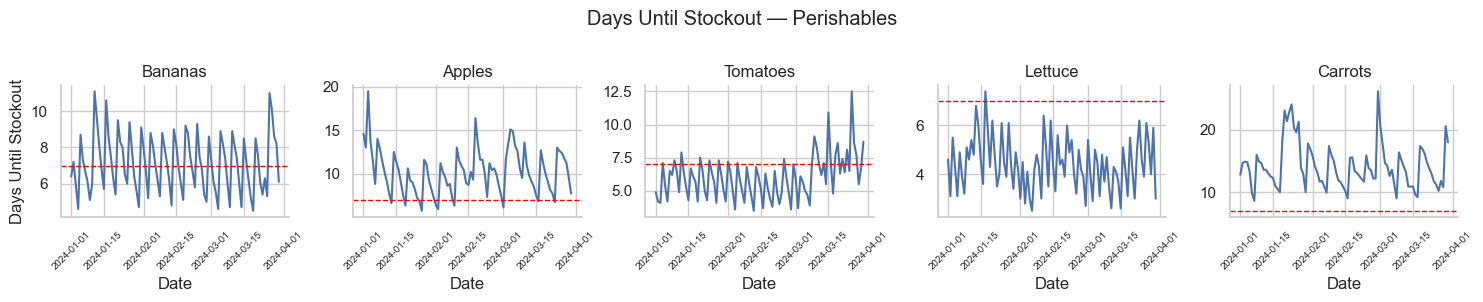

In [11]:
# Vizualizing days_until_stockout over time
perishables = df[df["category"] == "Perishable"]

g = sns.FacetGrid(perishables, col="name", col_wrap=5, height=3, sharey=False)
g.map_dataframe(sns.lineplot, x="sale_date", y="days_until_stockout")
g.set_titles("{col_name}")
g.set_axis_labels("Date", "Days Until Stockout")

for ax in g.axes.flatten():
    ax.axhline(y=7, color="red", linestyle="--", linewidth=1)  # 7-day warning line
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("Days Until Stockout — Perishables", y=1)
plt.tight_layout()
plt.show()

#### The dashed line in each graph is the threshold. Anything below the line means that the stock will last at most one week.

In [12]:
output_path = "../data/features.csv"
df.to_csv(output_path, index=False)
print(f"Dataset saved→ {output_path}")

Dataset saved→ ../data/features.csv
